# Analise de fluxo e tabela unificada - RetailRocket

Este notebook estuda os caminhos de relacionamento entre usuarios, eventos, itens, propriedades e categorias. A meta nao e repetir funil, volume ou sparsity do EDA 01, e sim transformar as relacoes do dataset em uma proposta concreta de tabela unificada para recomendacao, com cuidado explicito contra vazamento temporal.

Fluxo conceitual:

`visitorid -> events -> itemid -> item_properties -> category_tree`

A tabela de treino candidata deve ser ancorada em eventos. Cada linha representa uma interacao usuario-item em um instante, enriquecida apenas com informacoes disponiveis ate aquele timestamp.

## 0. Preparacao

Por padrao, os CSVs sao lidos de `data/raw/retailrocket/`. Para usar outro caminho, defina `RETAILROCKET_DATA_DIR`.

Parametros opcionais:

- `RETAILROCKET_PROPERTY_NROWS`: limita linhas lidas de cada arquivo de propriedades.
- `RETAILROCKET_FLOW_VISITOR_SAMPLE`: limita usuarios usados no estudo de caminhos.
- `RETAILROCKET_FEATURE_SAMPLE_ROWS`: limita a amostra cronologica usada para demonstrar a tabela unificada.
- `RETAILROCKET_TOP_ITEM_SAMPLE`: limita itens usados em diagnosticos de catalogo.

In [34]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def env_int(name: str, default: int | None = None) -> int | None:
    value = os.environ.get(name)
    if value in (None, ''):
        return default
    return int(value)


def sample_frame(
    frame: pd.DataFrame,
    max_rows: int | None,
    random_state: int = 42,
) -> pd.DataFrame:
    if max_rows is None or len(frame) <= max_rows:
        return frame.copy()
    return frame.sample(max_rows, random_state=random_state).copy()


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(
    os.environ.get('RETAILROCKET_DATA_DIR', PROJECT_ROOT / 'data' / 'raw' / 'retailrocket')
).expanduser()

events_path = DATA_DIR / 'events.csv'
category_tree_path = DATA_DIR / 'category_tree.csv'
item_property_paths = [
    DATA_DIR / 'item_properties_part1.csv',
    DATA_DIR / 'item_properties_part2.csv',
]
csv_paths = [events_path, category_tree_path, *item_property_paths]

missing_files = [path.name for path in csv_paths if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f"CSV(s) nao encontrados: {', '.join(missing_files)}. "
        'Ajuste RETAILROCKET_DATA_DIR ou coloque os arquivos em data/raw/retailrocket/.'
    )

PROPERTY_NROWS = env_int('RETAILROCKET_PROPERTY_NROWS', 500_000)
FLOW_VISITOR_SAMPLE = env_int('RETAILROCKET_FLOW_VISITOR_SAMPLE', 30_000)
FEATURE_SAMPLE_ROWS = env_int('RETAILROCKET_FEATURE_SAMPLE_ROWS', 100_000)
TOP_ITEM_SAMPLE = env_int('RETAILROCKET_TOP_ITEM_SAMPLE', 50_000)
EVENT_ORDER = ['view', 'addtocart', 'transaction']

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Leitura, amostras e mapa de trabalho

As datas sao convertidas para UTC. O notebook cria amostras explicitas para estudo de fluxo e prototipo de features, enquanto preserva a leitura da tabela de eventos para referencia de chaves e cobertura.

In [35]:
events = pd.read_csv(events_path)
events['event_time'] = pd.to_datetime(events['timestamp'], unit='ms', utc=True)
events = events.sort_values(['event_time', 'visitorid', 'itemid']).reset_index(drop=True)
events.insert(0, 'event_id', pd.RangeIndex(start=1, stop=len(events) + 1))

category_tree = pd.read_csv(category_tree_path)

item_properties = pd.concat(
    [pd.read_csv(path, nrows=PROPERTY_NROWS) for path in item_property_paths],
    ignore_index=True,
)
item_properties['property_time'] = pd.to_datetime(
    item_properties['timestamp'], unit='ms', utc=True
)
item_properties['property'] = item_properties['property'].astype('string')
item_properties['value'] = item_properties['value'].astype('string')

sampled_visitors = events['visitorid'].drop_duplicates().sample(
    min(FLOW_VISITOR_SAMPLE, events['visitorid'].nunique()),
    random_state=42,
)
flow_events = events[events['visitorid'].isin(sampled_visitors)].copy()
flow_events = flow_events.sort_values(['visitorid', 'event_time', 'itemid']).reset_index(drop=True)

first_property_time = item_properties['property_time'].min()
feature_source = events[events['event_time'].ge(first_property_time)].copy()
feature_events = feature_source.head(min(FEATURE_SAMPLE_ROWS, len(feature_source))).copy().reset_index(drop=True)

read_summary = pd.DataFrame(
    {
        'base': ['events', 'flow_events', 'feature_events', 'category_tree', 'item_properties'],
        'papel': [
            'referencia completa de eventos',
            'amostra por usuarios para sequencias',
            'amostra cronologica para tabela unificada, apos primeiro snapshot de propriedades',
            'hierarquia de categorias',
            'amostra/changelog de propriedades de item',
        ],
        'linhas': [len(events), len(flow_events), len(feature_events), len(category_tree), len(item_properties)],
        'inicio': [
            events['event_time'].min(),
            flow_events['event_time'].min(),
            feature_events['event_time'].min(),
            pd.NaT,
            item_properties['property_time'].min(),
        ],
        'fim': [
            events['event_time'].max(),
            flow_events['event_time'].max(),
            feature_events['event_time'].max(),
            pd.NaT,
            item_properties['property_time'].max(),
        ],
    }
)

display(Markdown('Ajuste os limites no bloco 0 se quiser rodar com amostras maiores.'))
display(read_summary)
display(feature_events[['event_id', 'event_time', 'visitorid', 'event', 'itemid', 'transactionid']].head())

Ajuste os limites no bloco 0 se quiser rodar com amostras maiores.

,base,papel,linhas,inicio,fim
0,events,referencia completa de eventos,2756101,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:47.788000+00:00
1,flow_events,amostra por usuarios para sequencias,59661,2015-05-03 03:06:03.403000+00:00,2015-09-18 02:55:02.366000+00:00
2,feature_events,"amostra cronologica para tabela unificada, apos primeiro snapshot de propriedades",100000,2015-05-10 03:00:09.663000+00:00,2015-05-15 02:58:01.719000+00:00
3,category_tree,hierarquia de categorias,1669,NaT,NaT
4,item_properties,amostra/changelog de propriedades de item,1000000,2015-05-10 03:00:00+00:00,2015-09-13 03:00:00+00:00


,event_id,event_time,visitorid,event,itemid,transactionid
0,137194,2015-05-10 03:00:09.663000+00:00,350663,view,325406,NaN
1,137195,2015-05-10 03:00:10.854000+00:00,826796,view,40046,NaN
2,137196,2015-05-10 03:00:41.016000+00:00,1368624,view,282472,NaN
3,137197,2015-05-10 03:00:46.215000+00:00,495446,view,112466,NaN
4,137198,2015-05-10 03:00:58.815000+00:00,1382836,view,277547,NaN


## 2. Mapa de relacionamento entre tabelas

Antes de calcular features, precisamos declarar os caminhos de join e onde cada relacionamento pode gerar valor. Esta secao substitui uma nova leitura de funil por um mapa de entidades, chaves e risco temporal.

In [36]:
relationship_map = pd.DataFrame(
    [
        ('visitorid', 'events', 'events historico', 'visitorid + event_time', 'sequencia, recencia, diversidade', 'usar apenas eventos anteriores'),
        ('itemid', 'events', 'item_properties', 'itemid + tempo', 'categoria, disponibilidade, tokens de conteudo', 'merge_asof por item'),
        ('categoryid', 'item_properties', 'category_tree', 'categoryid', 'familia de catalogo e ancestrais', 'derivar apos categoryid_asof'),
        ('event', 'events', 'label/target', 'linha atual', 'view/addtocart/transaction como alvo ou peso', 'nao usar label futuro como feature'),
        ('transactionid', 'events', 'target de compra', 'linha atual', 'confirmacao de transacao', 'nao usar como entrada preditiva'),
    ],
    columns=['entidade', 'origem', 'destino', 'chave_join', 'valor_analitico', 'regra_temporal'],
)

property_item_ids = set(item_properties['itemid'].dropna().unique())
category_item_ids = set(item_properties.loc[item_properties['property'].eq('categoryid'), 'itemid'].dropna().unique())
available_item_ids = set(item_properties.loc[item_properties['property'].eq('available'), 'itemid'].dropna().unique())
coverage_summary = pd.DataFrame(
    {
        'metrica': [
            'itens_unicos_events',
            'itens_unicos_item_properties_amostra',
            'itens_com_categoryid_na_amostra',
            'itens_com_available_na_amostra',
            'pct_linhas_feature_events_com_item_em_properties',
            'pct_linhas_feature_events_com_item_com_categoryid',
            'pct_linhas_feature_events_com_item_com_available',
            'categorias_category_tree',
            'usuarios_flow_events',
        ],
        'valor': [
            events['itemid'].nunique(),
            item_properties['itemid'].nunique(),
            len(category_item_ids),
            len(available_item_ids),
            round(feature_events['itemid'].isin(property_item_ids).mean() * 100, 2),
            round(feature_events['itemid'].isin(category_item_ids).mean() * 100, 2),
            round(feature_events['itemid'].isin(available_item_ids).mean() * 100, 2),
            category_tree['categoryid'].nunique(),
            flow_events['visitorid'].nunique(),
        ],
    }
)

display(relationship_map)
display(coverage_summary)

,entidade,origem,destino,chave_join,valor_analitico,regra_temporal
0,visitorid,events,events historico,visitorid + event_time,"sequencia, recencia, diversidade",usar apenas eventos anteriores
1,itemid,events,item_properties,itemid + tempo,"categoria, disponibilidade, tokens de conteudo",merge_asof por item
2,categoryid,item_properties,category_tree,categoryid,familia de catalogo e ancestrais,derivar apos categoryid_asof
3,event,events,label/target,linha atual,view/addtocart/transaction como alvo ou peso,nao usar label futuro como feature
4,transactionid,events,target de compra,linha atual,confirmacao de transacao,nao usar como entrada preditiva


,metrica,valor
0,itens_unicos_events,235061.00
1,itens_unicos_item_properties_amostra,342803.00
2,itens_com_categoryid_na_amostra,27932.00
3,itens_com_available_na_amostra,41905.00
4,pct_linhas_feature_events_com_item_em_properties,81.23
5,pct_linhas_feature_events_com_item_com_categoryid,7.45
6,pct_linhas_feature_events_com_item_com_available,20.72
7,categorias_category_tree,1669.00
8,usuarios_flow_events,30000.00


## 3. Caminhos entre eventos

Esta etapa olha transicoes imediatas por usuario. A matriz mostra, por exemplo, quantas vezes um `view` foi seguido de outro `view`, de `addtocart` ou de `transaction`.

In [37]:
ordered_events = flow_events.sort_values(['visitorid', 'event_time', 'itemid']).copy()
ordered_events['next_event'] = ordered_events.groupby('visitorid')['event'].shift(-1)
ordered_events['next_itemid'] = ordered_events.groupby('visitorid')['itemid'].shift(-1)
ordered_events['minutes_to_next'] = (
    ordered_events.groupby('visitorid')['event_time'].shift(-1)
    - ordered_events['event_time']
).dt.total_seconds().div(60)

transition_matrix = pd.crosstab(ordered_events['event'], ordered_events['next_event'])
transition_matrix = transition_matrix.reindex(index=EVENT_ORDER, columns=EVENT_ORDER).fillna(0).astype(int)

same_item_transitions = ordered_events[ordered_events['itemid'].eq(ordered_events['next_itemid'])]
same_item_matrix = pd.crosstab(same_item_transitions['event'], same_item_transitions['next_event'])
same_item_matrix = same_item_matrix.reindex(index=EVENT_ORDER, columns=EVENT_ORDER).fillna(0).astype(int)

transition_rates = transition_matrix.div(transition_matrix.sum(axis=1).replace(0, pd.NA), axis=0).fillna(0)
transition_rates = (transition_rates * 100).round(2)

same_item_rates = same_item_matrix.div(same_item_matrix.sum(axis=1).replace(0, pd.NA), axis=0).fillna(0)
same_item_rates = (same_item_rates * 100).round(2)

display(Markdown(f'Transicoes calculadas sobre **{len(flow_events):,} eventos** de **{flow_events["visitorid"].nunique():,} usuarios**.'))
display(Markdown('Transicoes imediatas entre eventos, independentemente do item.'))
display(transition_matrix)
display(transition_rates)
display(Markdown('Transicoes imediatas no mesmo item.'))
display(same_item_matrix)
display(same_item_rates)

Transicoes calculadas sobre **59,661 eventos** de **30,000 usuarios**.

Transicoes imediatas entre eventos, independentemente do item.

next_event,view,addtocart,transaction
event,,,
view,27083,1086,113
addtocart,682,221,221
transaction,168,6,81


next_event,view,addtocart,transaction
event,,,
view,95.76,3.84,0.40
addtocart,60.68,19.66,19.66
transaction,65.88,2.35,31.76


Transicoes imediatas no mesmo item.

next_event,view,addtocart,transaction
event,,,
view,7344,894,80
addtocart,283,71,201
transaction,78,4,0


next_event,view,addtocart,transaction
event,,,
view,88.29,10.75,0.96
addtocart,50.99,12.79,36.22
transaction,95.12,4.88,0.00


## 4. Exemplos de caminhos por usuario

Para nao gerar strings enormes em usuarios muito ativos, esta visao usa uma amostra configuravel de usuarios e limita cada caminho aos primeiros eventos observados.

In [38]:
visitor_paths = (
    ordered_events.groupby('visitorid')['event']
    .apply(lambda values: ' > '.join(values.head(8)))
    .value_counts()
    .head(20)
    .rename_axis('caminho')
    .to_frame('usuarios')
)

visitor_outcomes = (
    ordered_events.groupby('visitorid')['event']
    .agg(
        eventos='size',
        viu=lambda values: int((values == 'view').any()),
        adicionou=lambda values: int((values == 'addtocart').any()),
        comprou=lambda values: int((values == 'transaction').any()),
    )
)
visitor_outcomes['assinatura'] = (
    'view=' + visitor_outcomes['viu'].astype(str)
    + ' addtocart=' + visitor_outcomes['adicionou'].astype(str)
    + ' transaction=' + visitor_outcomes['comprou'].astype(str)
)
outcome_summary = visitor_outcomes['assinatura'].value_counts().rename_axis('assinatura').to_frame('usuarios')

display(Markdown(f'Caminhos derivados da amostra `flow_events`: **{ordered_events["visitorid"].nunique():,} usuarios**.'))
display(visitor_paths)
display(outcome_summary)

Caminhos derivados da amostra `flow_events`: **30,000 usuarios**.

,usuarios
caminho,
view,21399
view > view,4255
view > view > view,1527
view > view > view > view,666
view > view > view > view > view > view > view > view,547
view > view > view > view > view,422
view > view > view > view > view > view,248
view > view > view > view > view > view > view,168
view > addtocart,102


,usuarios
assinatura,
view=1 addtocart=0 transaction=0,29160
view=1 addtocart=1 transaction=0,507
view=1 addtocart=1 transaction=1,238
view=0 addtocart=1 transaction=0,50
view=1 addtocart=0 transaction=1,32
view=0 addtocart=1 transaction=1,10
view=0 addtocart=0 transaction=1,3


## 5. Tempo entre interacoes

Recencia e intervalo entre eventos sao sinais importantes para recomendacao. Esta celula mede o tempo desde a interacao anterior do mesmo usuario.

,count,mean,std,min,50%,75%,90%,99%,max
event,,,,,,,,,
addtocart,1313.0,366.263241,4962.607591,0.0,0.675967,2.011167,7.211363,3560.549541,111594.488767
transaction,415.0,67.692114,871.160275,0.0,2.879050,6.209675,11.880443,296.686800,16458.074067
view,27933.0,3560.235462,15118.335203,0.0,2.418750,75.936433,4406.893107,83751.099511,190176.511933


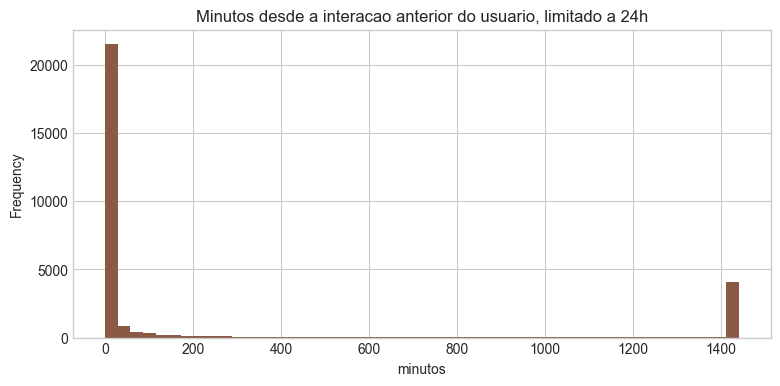

In [39]:
ordered_events['minutes_since_previous'] = (
    ordered_events['event_time']
    - ordered_events.groupby('visitorid')['event_time'].shift(1)
).dt.total_seconds().div(60)

delta_profile = ordered_events.groupby('event')['minutes_since_previous'].describe(
    percentiles=[0.5, 0.75, 0.9, 0.99]
)

display(delta_profile)

plot_data = ordered_events['minutes_since_previous'].dropna().clip(upper=24 * 60)
ax = plot_data.plot(kind='hist', bins=50, figsize=(9, 4), color='#8a5a44')
ax.set_title('Minutos desde a interacao anterior do usuario, limitado a 24h')
ax.set_xlabel('minutos')
plt.show()

## 6. Relacionamento item, categoria e conversao

Esta visao usa o ultimo `categoryid` conhecido por item apenas para exploracao. Na tabela de treino, a categoria precisa ser obtida por join temporal ate o instante do evento.

In [40]:
def latest_item_property(properties: pd.DataFrame, property_name: str, output: str) -> pd.DataFrame:
    subset = properties[properties['property'].eq(property_name)].copy()
    if subset.empty:
        return pd.DataFrame(columns=['itemid', output])
    latest = subset.sort_values('property_time').drop_duplicates('itemid', keep='last')
    return latest[['itemid', 'value']].rename(columns={'value': output})


latest_category = latest_item_property(item_properties, 'categoryid', 'categoryid')
if latest_category.empty:
    display(Markdown('Nao ha `categoryid` na leitura atual de `item_properties`.'))
else:
    latest_category['categoryid'] = pd.to_numeric(latest_category['categoryid'], errors='coerce').astype('Int64')
    events_with_category = feature_events.merge(latest_category, on='itemid', how='left')
    category_counts = pd.crosstab(events_with_category['categoryid'], events_with_category['event'])
    category_counts = category_counts.reindex(columns=EVENT_ORDER).fillna(0).astype(int)
    category_counts['total'] = category_counts[EVENT_ORDER].sum(axis=1)
    category_counts['transaction_por_view'] = (
        category_counts['transaction'] / category_counts['view'].where(category_counts['view'] > 0)
    ).fillna(0).round(6)
    category_counts['pct_feature_events'] = (
        category_counts['total'] / len(feature_events) * 100
    ).round(2)
    category_counts = category_counts.reset_index().merge(
        category_tree.rename(columns={'parentid': 'category_parentid'}),
        on='categoryid',
        how='left',
    )
    display(Markdown('Previa de categoria usando ultimo `categoryid` conhecido na amostra de propriedades. A tabela final deve usar `merge_asof`.'))
    display(category_counts.sort_values('total', ascending=False).head(20))

Previa de categoria usando ultimo `categoryid` conhecido na amostra de propriedades. A tabela final deve usar `merge_asof`.

,categoryid,view,addtocart,transaction,total,transaction_por_view,pct_feature_events,category_parentid
151,491,666,17,1,684,0.001502,0.68,679.0
513,1613,265,4,1,270,0.003774,0.27,250.0
216,683,186,3,1,190,0.005376,0.19,1606.0
473,1483,170,2,0,172,0.000000,0.17,561.0
330,1051,150,3,0,153,0.000000,0.15,955.0
407,1279,145,0,0,145,0.000000,0.14,1606.0
353,1120,119,4,0,123,0.000000,0.12,250.0
71,256,95,6,4,105,0.042105,0.10,1257.0
15,56,99,0,0,99,0.000000,0.10,1497.0
519,1625,83,1,0,84,0.000000,0.08,1141.0


## 7. Prontidao de features historicas

Em vez de repetir a long tail do EDA 01, esta secao mede um ponto operacional: quantas linhas da amostra teriam historico anterior suficiente para features de usuario e item.

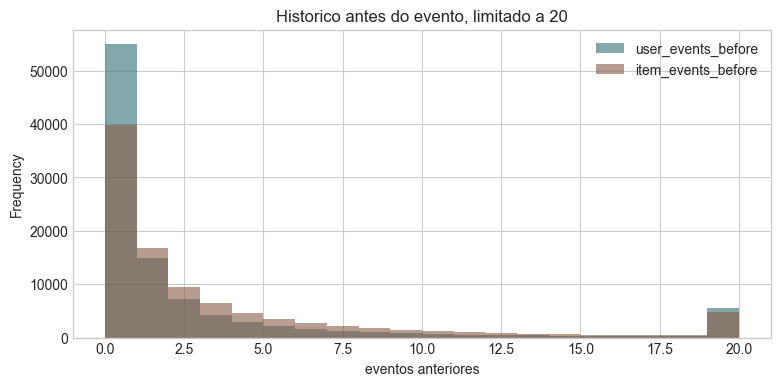

,metrica,valor
0,linhas_feature_events,100000.00
1,pct_sem_historico_usuario,54.94
2,pct_sem_historico_item,39.89
3,pct_com_usuario_e_item_historicos,34.01
4,p95_user_events_before,22.00
5,p95_item_events_before,18.00


In [41]:
feature_readiness = feature_events.copy()
feature_readiness['user_events_before'] = feature_readiness.groupby('visitorid').cumcount()
feature_readiness['item_events_before'] = feature_readiness.groupby('itemid').cumcount()
feature_readiness['has_user_history'] = feature_readiness['user_events_before'].gt(0)
feature_readiness['has_item_history'] = feature_readiness['item_events_before'].gt(0)

readiness_summary = pd.DataFrame(
    {
        'metrica': [
            'linhas_feature_events',
            'pct_sem_historico_usuario',
            'pct_sem_historico_item',
            'pct_com_usuario_e_item_historicos',
            'p95_user_events_before',
            'p95_item_events_before',
        ],
        'valor': [
            len(feature_readiness),
            round((~feature_readiness['has_user_history']).mean() * 100, 2),
            round((~feature_readiness['has_item_history']).mean() * 100, 2),
            round((feature_readiness['has_user_history'] & feature_readiness['has_item_history']).mean() * 100, 2),
            feature_readiness['user_events_before'].quantile(0.95),
            feature_readiness['item_events_before'].quantile(0.95),
        ],
    }
)

ax = feature_readiness[['user_events_before', 'item_events_before']].clip(upper=20).plot(
    kind='hist', bins=20, alpha=0.6, figsize=(9, 4), color=['#2f6f73', '#8a5a44']
)
ax.set_title('Historico antes do evento, limitado a 20')
ax.set_xlabel('eventos anteriores')
plt.show()

display(readiness_summary)

## 8. Melhor caminho de join: super tabela de evento

O melhor caminho e manter `events` como grao principal: uma linha por evento. Criamos `event_id` para identificar cada linha e juntamos propriedades do item por tempo, pegando o ultimo valor conhecido antes ou exatamente no momento do evento. Assim `categoryid` e `available` representam a situacao do item naquele instante, nao um valor futuro.

A super tabela traduz diretamente apenas os `value` das propriedades documentadas como nao hasheadas: `categoryid` e `available`. Os demais `value` continuam anonimos/hasheados e devem ser tratados depois como tokens ou atributos derivados; o detalhamento dessa estrutura esta no notebook `02_retailrocket_field_value_analysis.ipynb`.

In [42]:
join_plan = pd.DataFrame(
    [
        (1, 'Base', '`events` ordenado por `event_time`', 'criar `event_id` e manter uma linha por evento'),
        (2, 'Categoria', "`item_properties[property == 'categoryid']`", '`merge_asof` por `itemid`, `property_time <= event_time`'),
        (3, 'Disponibilidade', "`item_properties[property == 'available']`", '`merge_asof` por `itemid`, `property_time <= event_time`'),
        (4, 'Hierarquia', '`category_tree`', 'join simples `categoryid_asof -> categoryid`'),
        (5, 'Historico opcional', '`events` anteriores', 'features com janela temporal, sempre antes do evento atual'),
    ],
    columns=['passo', 'bloco', 'fonte', 'regra'],
)

display(join_plan)

display(
    Markdown(
        """
**Formato da query/pipeline.** Em SQL puro isso costuma virar janela temporal (`ROW_NUMBER`) ou join lateral; em pandas usamos `merge_asof`.

```sql
WITH event_base AS (
  SELECT
    ROW_NUMBER() OVER (ORDER BY event_time, visitorid, itemid, event) AS event_id,
    event_time,
    visitorid,
    event,
    itemid,
    transactionid
  FROM events
),
category_at_event AS (
  SELECT event_id, value AS categoryid_asof, property_time AS categoryid_asof_time
  FROM latest item_properties row
  WHERE property = 'categoryid'
    AND item_properties.itemid = event_base.itemid
    AND property_time <= event_time
),
available_at_event AS (
  SELECT event_id, value AS available_asof, property_time AS available_asof_time
  FROM latest item_properties row
  WHERE property = 'available'
    AND item_properties.itemid = event_base.itemid
    AND property_time <= event_time
)
SELECT *
FROM event_base
LEFT JOIN category_at_event USING (event_id)
LEFT JOIN available_at_event USING (event_id)
LEFT JOIN category_tree ON categoryid_asof = category_tree.categoryid;
```
        """
    )
)

,passo,bloco,fonte,regra
0,1,Base,`events` ordenado por `event_time`,criar `event_id` e manter uma linha por evento
1,2,Categoria,`item_properties[property == 'categoryid']`,"`merge_asof` por `itemid`, `property_time <= event_time`"
2,3,Disponibilidade,`item_properties[property == 'available']`,"`merge_asof` por `itemid`, `property_time <= event_time`"
3,4,Hierarquia,`category_tree`,join simples `categoryid_asof -> categoryid`
4,5,Historico opcional,`events` anteriores,"features com janela temporal, sempre antes do evento atual"



**Formato da query/pipeline.** Em SQL puro isso costuma virar janela temporal (`ROW_NUMBER`) ou join lateral; em pandas usamos `merge_asof`.

```sql
WITH event_base AS (
  SELECT
    ROW_NUMBER() OVER (ORDER BY event_time, visitorid, itemid, event) AS event_id,
    event_time,
    visitorid,
    event,
    itemid,
    transactionid
  FROM events
),
category_at_event AS (
  SELECT event_id, value AS categoryid_asof, property_time AS categoryid_asof_time
  FROM latest item_properties row
  WHERE property = 'categoryid'
    AND item_properties.itemid = event_base.itemid
    AND property_time <= event_time
),
available_at_event AS (
  SELECT event_id, value AS available_asof, property_time AS available_asof_time
  FROM latest item_properties row
  WHERE property = 'available'
    AND item_properties.itemid = event_base.itemid
    AND property_time <= event_time
)
SELECT *
FROM event_base
LEFT JOIN category_at_event USING (event_id)
LEFT JOIN available_at_event USING (event_id)
LEFT JOIN category_tree ON categoryid_asof = category_tree.categoryid;
```
        

In [43]:
def property_changelog(
    properties: pd.DataFrame,
    property_name: str,
    value_column: str,
) -> pd.DataFrame:
    subset = properties[properties['property'].eq(property_name)].copy()
    if subset.empty:
        return pd.DataFrame(columns=['itemid', 'property_time', value_column])
    return (
        subset[['itemid', 'property_time', 'value']]
        .dropna(subset=['itemid', 'property_time'])
        .sort_values(['property_time', 'itemid'])
        .rename(columns={'value': value_column})
    )


def join_property_at_event(
    event_base: pd.DataFrame,
    properties: pd.DataFrame,
    property_name: str,
    value_column: str,
) -> pd.DataFrame:
    changelog = property_changelog(properties, property_name, value_column)
    if changelog.empty:
        return pd.DataFrame({'event_id': event_base['event_id'], value_column: pd.NA})
    left = event_base[['event_id', 'itemid', 'event_time']].sort_values(['event_time', 'itemid'])
    joined = pd.merge_asof(
        left,
        changelog,
        left_on='event_time',
        right_on='property_time',
        by='itemid',
        direction='backward',
    )
    return joined[['event_id', value_column, 'property_time']].rename(
        columns={'property_time': f'{value_column}_time'}
    )


feature_rows = min(FEATURE_SAMPLE_ROWS or len(feature_events), len(feature_events))
super_event_table = feature_events.head(feature_rows).copy().reset_index(drop=True)

super_event_table['event_month'] = super_event_table['event_time'].dt.strftime('%Y-%m')
super_event_table['event_dayofweek'] = super_event_table['event_time'].dt.dayofweek
super_event_table['event_hour'] = super_event_table['event_time'].dt.hour
super_event_table['target_transaction'] = super_event_table['event'].eq('transaction').astype(int)
super_event_table['target_addtocart_or_transaction'] = super_event_table['event'].isin(['addtocart', 'transaction']).astype(int)
super_event_table['user_events_before'] = super_event_table.groupby('visitorid').cumcount()
super_event_table['item_events_before'] = super_event_table.groupby('itemid').cumcount()
super_event_table['user_minutes_since_previous'] = (
    super_event_table['event_time']
    - super_event_table.groupby('visitorid')['event_time'].shift(1)
).dt.total_seconds().div(60)
super_event_table['item_minutes_since_previous'] = (
    super_event_table['event_time']
    - super_event_table.groupby('itemid')['event_time'].shift(1)
).dt.total_seconds().div(60)

for property_name, value_column in [('categoryid', 'categoryid_asof'), ('available', 'available_asof')]:
    property_values = join_property_at_event(
        super_event_table,
        item_properties,
        property_name,
        value_column,
    )
    super_event_table = super_event_table.merge(property_values, on='event_id', how='left')

super_event_table['categoryid_asof'] = pd.to_numeric(
    super_event_table['categoryid_asof'], errors='coerce'
).astype('Int64')
super_event_table['available_asof'] = pd.to_numeric(
    super_event_table['available_asof'], errors='coerce'
).astype('Int64')
super_event_table = super_event_table.merge(
    category_tree.rename(columns={'categoryid': 'categoryid_asof', 'parentid': 'category_parentid'}),
    on='categoryid_asof',
    how='left',
)

super_columns = [
    'event_id',
    'event_time',
    'visitorid',
    'event',
    'itemid',
    'transactionid',
    'target_transaction',
    'target_addtocart_or_transaction',
    'event_month',
    'event_dayofweek',
    'event_hour',
    'categoryid_asof',
    'categoryid_asof_time',
    'category_parentid',
    'available_asof',
    'available_asof_time',
    'user_events_before',
    'user_minutes_since_previous',
    'item_events_before',
    'item_minutes_since_previous',
]

catalog_mask = super_event_table['categoryid_asof'].notna() | super_event_table['available_asof'].notna()
preview_table = pd.concat(
    [super_event_table[catalog_mask].head(10), super_event_table.head(10)],
    ignore_index=True,
).drop_duplicates('event_id')

missing_summary = (
    super_event_table[super_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename('pct_nulo')
    .to_frame()
)

future_category = super_event_table['categoryid_asof_time'].gt(super_event_table['event_time']).fillna(False)
future_available = super_event_table['available_asof_time'].gt(super_event_table['event_time']).fillna(False)
valid_category_tree = super_event_table['categoryid_asof'].dropna().isin(category_tree['categoryid'])
join_validation = pd.DataFrame(
    {
        'metrica': [
            'linhas_base_evento',
            'event_id_unico',
            'pct_categoryid_asof_preenchido',
            'pct_available_asof_preenchido',
            'violacoes_categoryid_futuro',
            'violacoes_available_futuro',
            'pct_categoryid_presente_category_tree',
        ],
        'valor': [
            len(super_event_table),
            super_event_table['event_id'].is_unique,
            round(super_event_table['categoryid_asof'].notna().mean() * 100, 2),
            round(super_event_table['available_asof'].notna().mean() * 100, 2),
            int(future_category.sum()),
            int(future_available.sum()),
            round(valid_category_tree.mean() * 100, 2) if len(valid_category_tree) else pd.NA,
        ],
    }
)

display(Markdown(f'Super tabela de evento em amostra cronologica: **{feature_rows:,} eventos**.'))
display(preview_table[super_columns].head(20))
display(Markdown('Validacao do caminho de join. As violacoes de futuro devem ser zero.'))
display(join_validation)
display(missing_summary)

Super tabela de evento em amostra cronologica: **100,000 eventos**.

,event_id,event_time,visitorid,event,itemid,transactionid,target_transaction,target_addtocart_or_transaction,event_month,event_dayofweek,event_hour,categoryid_asof,categoryid_asof_time,category_parentid,available_asof,available_asof_time,user_events_before,user_minutes_since_previous,item_events_before,item_minutes_since_previous
0,137225,2015-05-10 03:03:30.127000+00:00,532545,view,344071,NaN,0,0,2015-05,6,3,<NA>,NaT,NaN,1,2015-05-10 03:00:00+00:00,0,NaN,0,NaN
1,137231,2015-05-10 03:04:35.054000+00:00,109717,transaction,66811,10767.0,1,1,2015-05,6,3,<NA>,NaT,NaN,1,2015-05-10 03:00:00+00:00,0,NaN,0,NaN
2,137257,2015-05-10 03:08:11.383000+00:00,467649,view,35202,NaN,0,0,2015-05,6,3,<NA>,NaT,NaN,1,2015-05-10 03:00:00+00:00,0,NaN,0,NaN
3,137260,2015-05-10 03:08:23.472000+00:00,126574,view,200977,NaN,0,0,2015-05,6,3,405,2015-05-10 03:00:00+00:00,351.0,<NA>,NaT,0,NaN,0,NaN
4,137281,2015-05-10 03:09:38.552000+00:00,1257943,view,377810,NaN,0,0,2015-05,6,3,<NA>,NaT,NaN,1,2015-05-10 03:00:00+00:00,1,3.783517,0,NaN
5,137290,2015-05-10 03:10:24.577000+00:00,723811,view,188698,NaN,0,0,2015-05,6,3,1402,2015-05-10 03:00:00+00:00,250.0,<NA>,NaT,0,NaN,0,NaN
6,137311,2015-05-10 03:12:53.302000+00:00,174574,view,367203,NaN,0,0,2015-05,6,3,<NA>,NaT,NaN,0,2015-05-10 03:00:00+00:00,0,NaN,0,NaN
7,137333,2015-05-10 03:14:54.976000+00:00,1206272,view,37699,NaN,0,0,2015-05,6,3,<NA>,NaT,NaN,0,2015-05-10 03:00:00+00:00,0,NaN,0,NaN
8,137366,2015-05-10 03:18:24.983000+00:00,1064380,view,401285,NaN,0,0,2015-05,6,3,1120,2015-05-10 03:00:00+00:00,250.0,<NA>,NaT,2,0.455317,0,NaN
9,137377,2015-05-10 03:19:18.534000+00:00,587788,view,41351,NaN,0,0,2015-05,6,3,821,2015-05-10 03:00:00+00:00,1012.0,<NA>,NaT,0,NaN,0,NaN


Validacao do caminho de join. As violacoes de futuro devem ser zero.

,metrica,valor
0,linhas_base_evento,100000
1,event_id_unico,True
2,pct_categoryid_asof_preenchido,2.78
3,pct_available_asof_preenchido,3.5
4,violacoes_categoryid_futuro,0
5,violacoes_available_futuro,0
6,pct_categoryid_presente_category_tree,100.0


,pct_nulo
event_id,0.00
event_time,0.00
visitorid,0.00
event,0.00
itemid,0.00
transactionid,99.20
target_transaction,0.00
target_addtocart_or_transaction,0.00
event_month,0.00
event_dayofweek,0.00


## 9. Schema candidato

Este schema resume quais campos devem compor a tabela de treino futura. Ele separa chaves, labels, features temporais, historicas e de catalogo.

In [44]:
schema_candidate = pd.DataFrame(
    [
        ('event_id', 'derivada de events', 'identificador unico da linha de evento', 'chave primaria da super tabela', 'gerar apos ordenar eventos'),
        ('event_time', 'events', 'timestamp do evento', 'chave temporal', 'nunca usar dados posteriores'),
        ('visitorid', 'events', 'usuario anonimo', 'chave/embedding', 'ok'),
        ('itemid', 'events', 'item anonimo', 'chave/embedding', 'ok'),
        ('event', 'events', 'tipo de interacao', 'label ou peso implicito', 'nao misturar label e feature'),
        ('transactionid', 'events', 'compra observada', 'label de transacao', 'nao usar como feature preditiva'),
        ('target_transaction', 'derivada', '1 quando evento e transaction', 'alvo binario', 'derivado apenas da linha atual'),
        ('event_month/dayofweek/hour', 'derivada', 'sazonalidade', 'feature temporal', 'ok'),
        ('user_events_before', 'events historico', 'historico do usuario antes do evento', 'feature comportamental', 'somente eventos anteriores'),
        ('item_events_before', 'events historico', 'historico do item antes do evento', 'feature de popularidade', 'somente eventos anteriores'),
        ('user_minutes_since_previous', 'events historico', 'recencia do usuario', 'feature comportamental', 'somente evento anterior'),
        ('item_minutes_since_previous', 'events historico', 'recencia do item', 'feature de catalogo', 'somente evento anterior'),
        ('categoryid_asof', 'item_properties', 'categoria conhecida no tempo', 'feature de catalogo', 'merge_asof por item e tempo'),
        ('categoryid_asof_time', 'item_properties', 'timestamp da categoria usada', 'auditoria temporal', 'deve ser <= event_time'),
        ('available_asof', 'item_properties', 'disponibilidade conhecida no tempo', 'feature temporal de item', 'merge_asof por item e tempo'),
        ('available_asof_time', 'item_properties', 'timestamp da disponibilidade usada', 'auditoria temporal', 'deve ser <= event_time'),
        ('category_parent_*', 'category_tree', 'ancestrais da categoria', 'feature hierarquica', 'usar apos categoryid_asof'),
        ('selected_property_tokens', 'item_properties', 'tokens hasheados filtrados', 'conteudo/embedding', 'filtrar por cobertura e frequencia'),
    ],
    columns=['campo', 'origem', 'descricao', 'uso', 'regra_anti_vazamento'],
)

display(schema_candidate)

,campo,origem,descricao,uso,regra_anti_vazamento
0,event_id,derivada de events,identificador unico da linha de evento,chave primaria da super tabela,gerar apos ordenar eventos
1,event_time,events,timestamp do evento,chave temporal,nunca usar dados posteriores
2,visitorid,events,usuario anonimo,chave/embedding,ok
3,itemid,events,item anonimo,chave/embedding,ok
4,event,events,tipo de interacao,label ou peso implicito,nao misturar label e feature
5,transactionid,events,compra observada,label de transacao,nao usar como feature preditiva
6,target_transaction,derivada,1 quando evento e transaction,alvo binario,derivado apenas da linha atual
7,event_month/dayofweek/hour,derivada,sazonalidade,feature temporal,ok
8,user_events_before,events historico,historico do usuario antes do evento,feature comportamental,somente eventos anteriores
9,item_events_before,events historico,historico do item antes do evento,feature de popularidade,somente eventos anteriores


## 10. Decisoes para engenharia de features

- A super tabela deve ter grao de evento: uma linha por `event_id`.
- O join principal e `events.itemid = item_properties.itemid` com `property_time <= event_time`, usando o ultimo valor conhecido.
- A traducao direta de `value` na super tabela deve ficar restrita a `property == 'categoryid'` e `property == 'available'`.
- `categoryid_asof` e `available_asof` devem guardar tambem `*_time` para auditar que nenhum valor futuro entrou.
- `categoryid_asof` casa com `category_tree.categoryid` para trazer `category_parentid` e futuros ancestrais.
- Historicos de usuario/item entram depois como features opcionais de janela temporal, sempre antes do evento atual.
- Os demais `value` de `item_properties` seguem hasheados/anonimos; o EDA 02 detalha essa estrutura e deve orientar filtros de cobertura, frequencia e estabilidade.